In [1]:
import matplotlib.pyplot as plt
import microarray as ma
import pandas as pd
import scanpy as sc
import seaborn as sns

import dtangle

In [2]:
adata_sc = sc.read_h5ad("./data/d141dc30-b521-4659-8349-b48bb0ed64bf.h5ad")

adata_sc.var = adata_sc.var.reset_index(names="ensemble_id").set_index("feature_name")
adata_sc.var.index = adata_sc.var.index.astype(str)
adata_sc.var.index.name = None
adata_sc.var_names_make_unique()
adata_sc

AnnData object with n_obs × n_vars = 107344 × 26837
    obs: 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'subclass.l2', 'subclass.l1', 'dataSource', 'sampletype', 'diseasetype', 'ClusterNumber', 'ClusterClass', 'tissuetype', 'celltype', 'disease_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'eGFR', 'BMI', 'diabetes_history', 'hypertension', 'assay_ontology_term_id', 'is_primary_data', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'SpecimenID', 'donor_id', 'suspension_type', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'ensemble_id', 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'feature_is_filtered', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'default_embedding', 'organism', 'organism_ontology_term_i

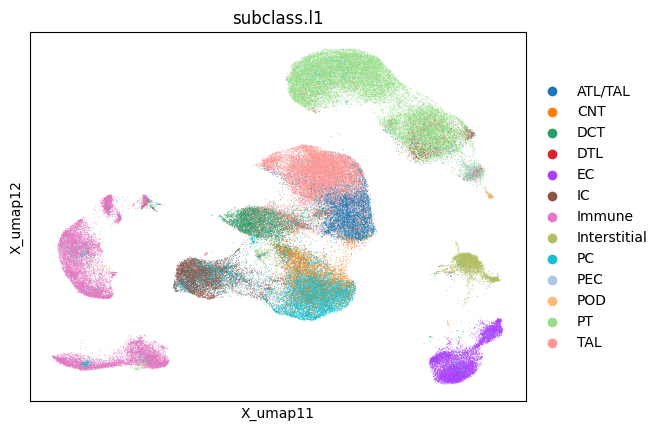

In [3]:
sc.pl.embedding(adata_sc, basis="X_umap1", color="subclass.l1")

In [4]:
sc.pp.subsample(adata_sc, fraction=0.1)

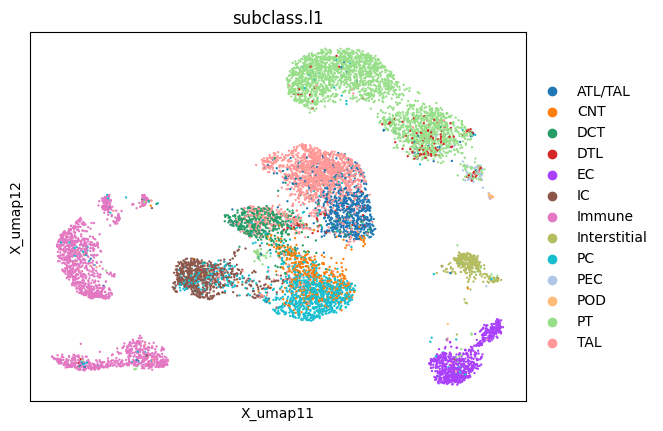

In [5]:
sc.pl.embedding(adata_sc, basis="X_umap1", color="subclass.l1")

In [6]:
adata_mi = sc.read_h5ad("../../microarray/examples/data/anca_sum.h5ad")
adata_mi

AnnData object with n_obs × n_vars = 6 × 18227
    obs: 'sample_name', 'cel_version', 'nrows', 'ncols', 'algorithm', 'condition', 'celfile'
    var: 'gene_id', 'n_probes', 'converged'
    uns: 'X_pca', 'normalization', 'summarization'
    obsm: 'X_pca'

<Axes: title={'center': 'PCA Plot'}, xlabel='PC1 (66.8%)', ylabel='PC2 (14.6%)'>

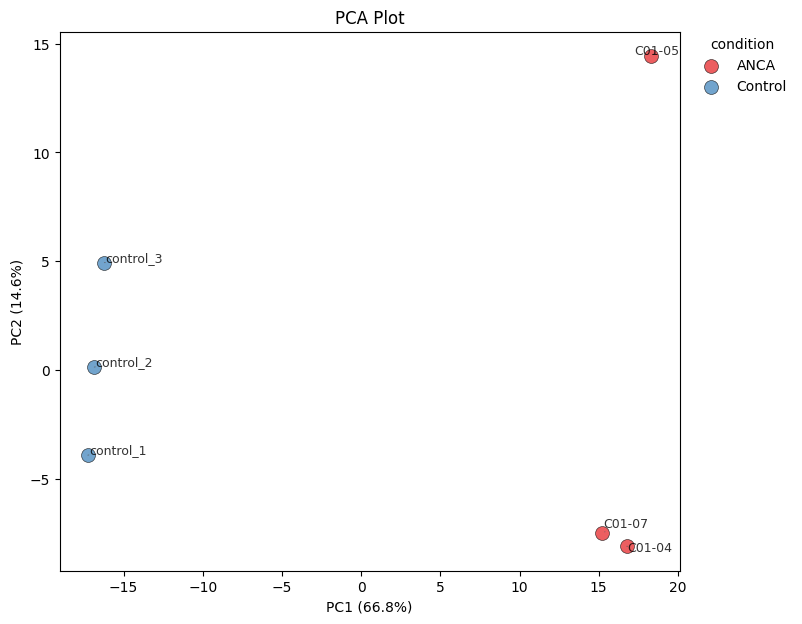

In [7]:
ma.pl.pca(adata_mi, colors="condition")

In [8]:
dtangle.deconvolut(
    adata_mi,
    references=adata_sc,
    reference_annotation_col="subclass.l1",
    data_type="microarray-gene",
)

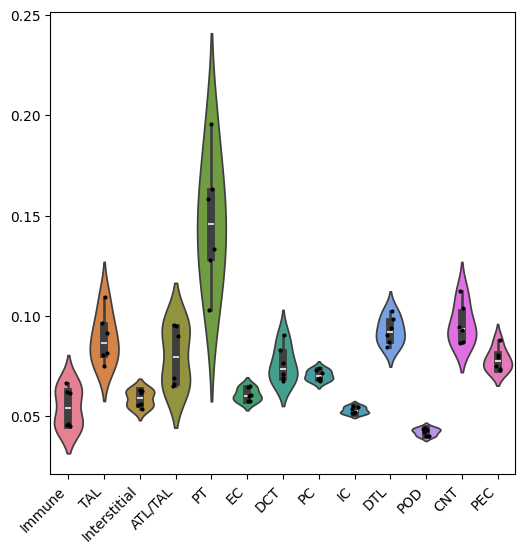

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))
sns.violinplot(adata_mi.obsm["dtangle"], ax=ax)
sns.stripplot(adata_mi.obsm["dtangle"], color="k", size=3, ax=ax)
_ = ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

Text(0.5, 1.0, 'Immune cell proportion\nANCA vs Control')

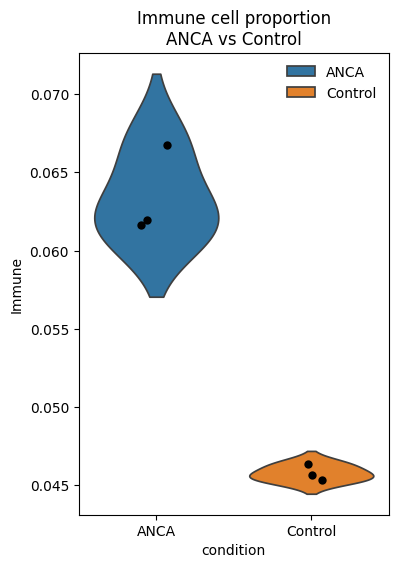

In [10]:
df = pd.DataFrame(adata_mi.obsm["dtangle"]["Immune"])
df["condition"] = ["ANCA"] * 3 + ["Control"] * 3

fig, ax = plt.subplots(figsize=(4, 6))
sns.violinplot(
    data=df,
    x="condition",
    y="Immune",
    hue="condition",
    inner=None,
    ax=ax,
    legend=True,
)
sns.stripplot(
    data=df,
    x="condition",
    y="Immune",
    color="k",
    size=6,
    ax=ax,
)
legend = ax.legend()
legend.set_frame_on(False)
ax.set_title("Immune cell proportion\nANCA vs Control")

Text(0.5, 1.0, 'PEC cell proportion\nANCA vs Control')

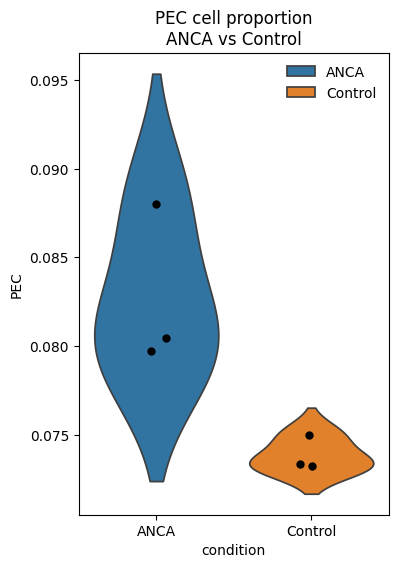

In [11]:
df = pd.DataFrame(adata_mi.obsm["dtangle"]["PEC"])
df["condition"] = ["ANCA"] * 3 + ["Control"] * 3

fig, ax = plt.subplots(figsize=(4, 6))
sns.violinplot(
    data=df,
    x="condition",
    y="PEC",
    hue="condition",
    inner=None,
    ax=ax,
    legend=True,
)
sns.stripplot(
    data=df,
    x="condition",
    y="PEC",
    color="k",
    size=6,
    ax=ax,
)
legend = ax.legend()
legend.set_frame_on(False)
ax.set_title("PEC cell proportion\nANCA vs Control")

### Differential proportions analysis using scanpro

In [18]:
out = dtangle.differential_proportion(
    adata_mi,
    conds_col="condition",
    samples_col="sample_name",
)

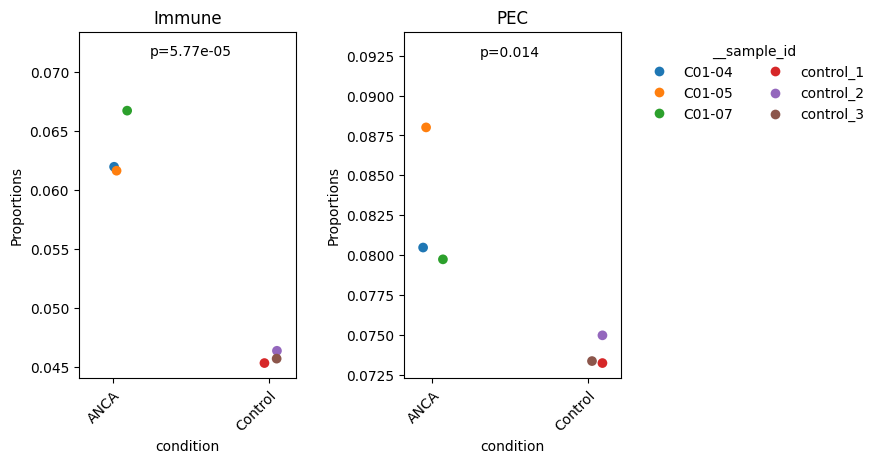

In [20]:
out.plot(
    clusters=["Immune", "PEC"],
)